# Data analyse and video creation

In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure
from numpy.polynomial import legendre
import pandas as pd
import pyvista as pv

In [13]:
file_path = 'dd_target_state.h5'

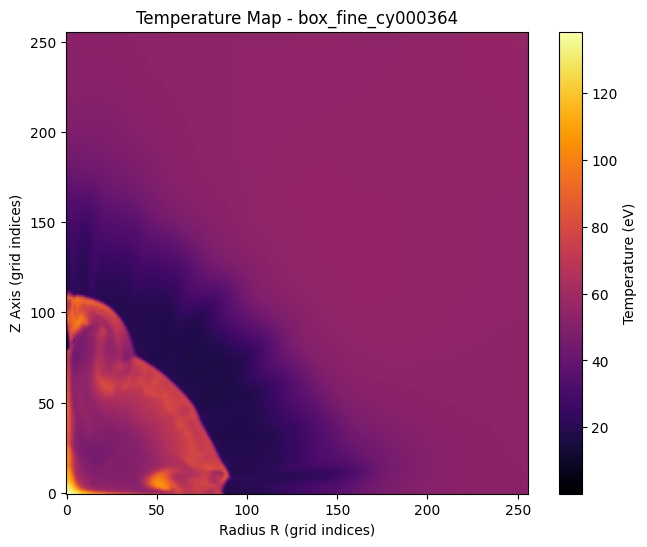

In [14]:
import h5py
import matplotlib.pyplot as plt

file_path = 'dd_target_state.h5'
indice_variable = 8  # 8 for Temperature, 12 for Pressure, etc.

with h5py.File(file_path, 'r') as f:
    # List and sort all time steps/cycles available in the file
    cles_temps = sorted([k for k in f.keys() if k.startswith('box_fine_cy')])
    
    # Select the very last cycle of the simulation to see peak compression
    cycle_a_afficher = cles_temps[-1] 
    
    # Extract the 2D grid data
    data_matrice = f[cycle_a_afficher][()]
    variable_2d = data_matrice[:, :, indice_variable]
    
    # Create the plot
    plt.figure(figsize=(8, 6))
    # Transpose (.T) to map Radius to X-axis and Z to Y-axis. 
    # origin='lower' places the (0,0) coordinate at the bottom-left.
    plt.imshow(variable_2d.T, cmap='inferno', origin='lower')
    
    plt.colorbar(label='Temperature (eV)') # Change the label if you are plotting Pressure!
    plt.title(f"Temperature Map - {cycle_a_afficher}")
    plt.xlabel("Radius R (grid indices)")
    plt.ylabel("Z Axis (grid indices)")
    plt.show()

## Video

In [15]:
variable_index = 5

with h5py.File(file_path, 'r') as f:
    time_keys = sorted([k for k in f.keys() if k.startswith('box_fine_cy')])
    first_dataset = f[time_keys[0]][()]
    nx, ny, _ = first_dataset.shape

grid = pv.ImageData(dimensions=(nx, ny, 1))

plotter = pv.Plotter(off_screen=True)
plotter.open_movie('compression_plasma_2D.mp4', framerate=10)

# Ajustement de la courbe d'opacité pour le rendu logarithmique
opacity_curve = [0.0, 0.1, 0.5, 1.0]

with h5py.File(file_path, 'r') as f:
    initial_data = f[time_keys[0]][()][:, :, variable_index]
    
    # SÉCURITÉ : L'échelle log ne tolère pas les valeurs <= 0. 
    # On clipse au niveau de ton niveau ambiant (1e-2)
    initial_data = np.clip(initial_data, 1e-2, None)
    grid.point_data["Density"] = initial_data.flatten(order="F")
    
    # MODIFICATIONS CLÉS : log_scale et clim fixes
    actor = plotter.add_mesh(
        grid,
        scalars="Density",
        cmap="inferno",
        opacity=opacity_curve,
        show_scalar_bar=True,
        log_scale=True,               # Échelle log pour voir à la fois le gaz et le CH solide
        clim=[1e-2, 1e4]              # Limites fixes (de 0.01 à 10 000 kg/m3) pour éviter le scintillement
    )
    
    plotter.camera_position = 'xy'
    plotter.set_background('black')
    
    for key_name in time_keys:
        data = f[key_name][()][:, :, variable_index]
        
        # On applique le même clip de sécurité à chaque pas de temps
        data = np.clip(data, 1e-2, None)
        
        # Mise à jour des scalaires (l'acteur conserve le mode log et le clim fixe)
        plotter.update_scalars(data.flatten(order="F"), render=False)
        
        plotter.write_frame()

plotter.close()
print("Vidéo correctement générée avec l'échelle optimisée !")

C:\Users\clara\AppData\Local\Temp\ipykernel_14904\3870715685.py:45: PyVistaDeprecationWarning: This method is deprecated and will be removed in a future version of PyVista. Directly modify the scalars of a mesh in-place instead.
  plotter.update_scalars(data.flatten(order="F"), render=False)


Vidéo correctement générée avec l'échelle optimisée !


## Density analize

In [16]:
def density_calculation(file_path, density_index=5, dt_fraction_index=6):
    """
    Calculates the evolution of the spatial average density of DT over time.
    Uses geometric weighting (2D axisymmetric) and isolates the DT using its fraction.
    """
    time_history = []
    average_dt_density_history = []

    with h5py.File(file_path, 'r') as f:
        # Retrieve and sort time cycles
        time_keys = sorted([k for k in f.keys() if k.startswith('box_fine_cy')])
        
        if not time_keys:
            print("Error: No cycle found in this file.")
            return pd.DataFrame()
        
        # Retrieve dimensions from the first cycle
        first_dataset = f[time_keys[0]][()]
        nx, ny = first_dataset.shape[0], first_dataset.shape[1]
        
        # Create the radius matrix R (to weight the volume Vi)
        R_1D = np.arange(nx) 
        R_2D = R_1D[:, np.newaxis] * np.ones((1, ny)) 
        
        for key_name in time_keys:
            dataset = f[key_name]
            
            # Extract time
            if 'time' in dataset.attrs:
                val = dataset.attrs['time']
                t = float(val[0]) if isinstance(val, np.ndarray) else float(val)
            else:
                t = float(key_name.split('cy')[-1])
            time_history.append(t)
            
            # Extract variables
            data_matrix = dataset[()]
            rho_i = data_matrix[:, :, density_index]
            f_i = data_matrix[:, :, dt_fraction_index]
            
            # Formula: Average weighted by volume (R) and DT fraction
            dt_mass_prop = np.sum(f_i * rho_i * R_2D)
            dt_volume_prop = np.sum(f_i * R_2D)
            
            if dt_volume_prop > 0:
                average_density = dt_mass_prop / dt_volume_prop
            else:
                average_density = 0.0
                
            average_dt_density_history.append(average_density)

    # Create the final DataFrame
    df_result = pd.DataFrame({
        'Time': time_history,
        'Average_DT_Density': average_dt_density_history
    })
    
    return df_result

## Execution

           Time  Average_DT_Density
0  0.000000e+00            0.000000
1  3.763729e-11            0.003936
2  4.106899e-11            0.007742
3  4.485971e-11            0.012153
4  4.904703e-11            0.017241


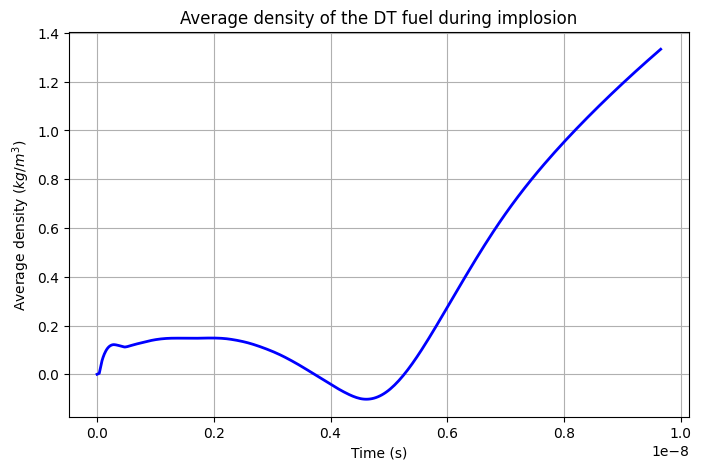

In [17]:
# Call the function (don't forget to check the index for dt_fraction_index!)
df_arwen = density_calculation('dd_target_state.h5', density_index=5, dt_fraction_index=6)

# Display the first rows to verify
print(df_arwen.head())

# Plotting the graph
plt.figure(figsize=(8, 5))
plt.plot(df_arwen['Time'], df_arwen['Average_DT_Density'], color='blue', linewidth=2)
plt.title("Average density of the DT fuel during implosion")
plt.xlabel("Time (s)")
plt.ylabel("Average density ($kg/m^3$)")
plt.grid(True)
plt.show()

## Slice radius integration

In [19]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# ==========================================
# 1. Chargement de la grille et des données ARWEN
# ==========================================

indice_variable = 5  # Grandeur physique à analyser (ex: Densité)

# Limites physiques de la boîte de simulation (définies par geometry.prob_hi)
R_max = 3.0e-3  # 3 mm
Z_max = 3.0e-3  # 3 mm

with h5py.File(file_path, 'r') as f:
    cles_temps = sorted([k for k in f.keys() if k.startswith('box_fine_cy')])
    # Extraction de la matrice hydrodynamique (Pas de temps final par exemple)
    matrice_arwen = f[cles_temps[-1]][()][:, :, indice_variable]
    nx, ny = matrice_arwen.shape

# Définition des coordonnées réelles des mailles pour l'interpolateur
r_coord = np.linspace(0, R_max, nx)
z_coord = np.linspace(0, Z_max, ny)

# Création du profil d'interpolation continu
# bounds_error=False et fill_value=0 gèrent proprement les rayons qui sortent de la boîte
interpolateur = RegularGridInterpolator((r_coord, z_coord), matrice_arwen, bounds_error=False, fill_value=0)

# ==========================================
# 2. Discrétisation en tranches (Abscisse curviligne s)
# ==========================================
num_steps = 500     # Nombre de tranches (segments) le long de chaque rayon
s_max = 1.2e-3      # Distance maximale d'intégration (1.2 mm pour traverser la couronne)
s_vec = np.linspace(0, s_max, num_steps)
ds = s_max / (num_steps - 1)

# ==========================================
# 3. Projection vectorielle des trajectoires (Zéro boucle for)
# ==========================================
# Extraction des positions et directions générées par ta fonction précédente
# all_rays_positions a pour forme (N_rayons, 2) -> [R_start, Z_start]
# all_rays_directions a pour forme (N_rayons, 2) -> [dir_r, dir_z]
R_start = all_rays_positions[:, 0]
Z_start = all_rays_positions[:, 1]
dir_r = all_rays_directions[:, 0]
dir_z = all_rays_directions[:, 1]

# Utilisation du mécanisme de broadcasting numpy pour générer instantanément la grille de coordonnées
# Dimensions résultantes pour R_tranches et Z_tranches : (N_rayons, num_steps)
R_tranches = R_start[:, np.newaxis] + dir_r[:, np.newaxis] * s_vec[np.newaxis, :]
Z_tranches = Z_start[:, np.newaxis] + dir_z[:, np.newaxis] * s_vec[np.newaxis, :]

# ==========================================
# 4. Échantillonnage et Intégration par tranche
# ==========================================
# Aplatissement des coordonnées pour réaliser l'interpolation en un seul appel matriciel
points_requete = np.column_stack((R_tranches.flatten(), Z_tranches.flatten()))
valeurs_interpolees_flat = interpolateur(points_requete)

# Restructuration du tableau sous la forme native (Rayons, Tranches)
valeurs_tranches = valeurs_interpolees_flat.reshape(R_tranches.shape)

# Intégration cumulative le long du profil curviligne (profil de chaque rayon)
profil_integre_cumule = np.cumsum(valeurs_tranches, axis=1) * ds

# Intégrale totale finale calculée pour chaque rayon distinct
integrale_totale_par_rayon = np.sum(valeurs_tranches, axis=1) * ds

print(f"Analyse terminée. {valeurs_tranches.shape[0]} rayons analysés sur {num_steps} tranches chacun.")

NameError: name 'all_rays_positions' is not defined